# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [12]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [13]:
df['Fare'].describe()


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [14]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [15]:
import matplotlib.pyplot as plt

# Create Age categories using .loc
df['AgeGroup'] = 'Unknown'
df.loc[df['Age'] < 13, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 13) & (df['Age'] < 18), 'AgeGroup'] = 'Teen'
df.loc[(df['Age'] >= 18) & (df['Age'] < 40), 'AgeGroup'] = 'Adult'
df.loc[(df['Age'] >= 40) & (df['Age'] < 60), 'AgeGroup'] = 'Middle Age'
df.loc[df['Age'] >= 60, 'AgeGroup'] = 'Senior'

# Create Fare categories using .loc
df['FareGroup'] = 'Unknown'
df.loc[df['Fare'] <= 10, 'FareGroup'] = 'Low Fare'
df.loc[(df['Fare'] > 10) & (df['Fare'] <= 30), 'FareGroup'] = 'Medium Fare'
df.loc[df['Fare'] > 30, 'FareGroup'] = 'High Fare'

print("I categorized Age into Child, Teen, Adult, Middle Age, Senior, and Unknown.")
print("I categorized Fare into Low Fare, Medium Fare, and High Fare based on the fare distribution.")
df[['Name', 'Age', 'AgeGroup', 'Fare', 'FareGroup']].head()

I categorized Age into Child, Teen, Adult, Middle Age, Senior, and Unknown.
I categorized Fare into Low Fare, Medium Fare, and High Fare based on the fare distribution.


,Name,Age,AgeGroup,Fare,FareGroup
0,"Braund, Mr. Owen Harris",22.0,Adult,7.2500,Low Fare
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,Adult,71.2833,High Fare
2,"Heikkinen, Miss. Laina",26.0,Adult,7.9250,Low Fare
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,Adult,53.1000,High Fare
4,"Allen, Mr. William Henry",35.0,Adult,8.0500,Low Fare


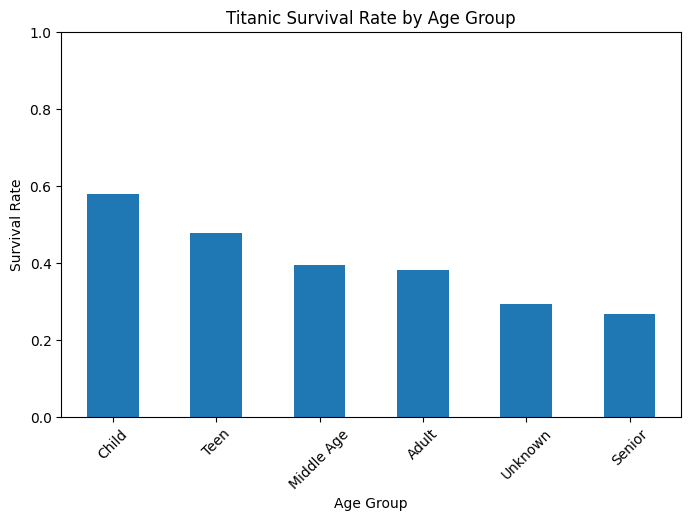

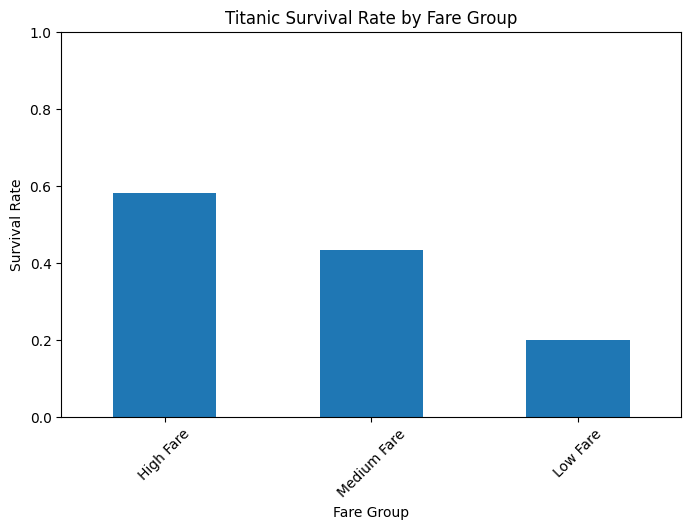

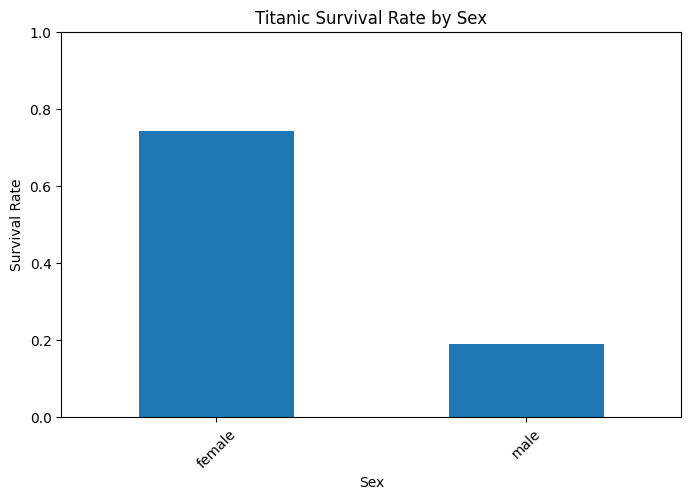

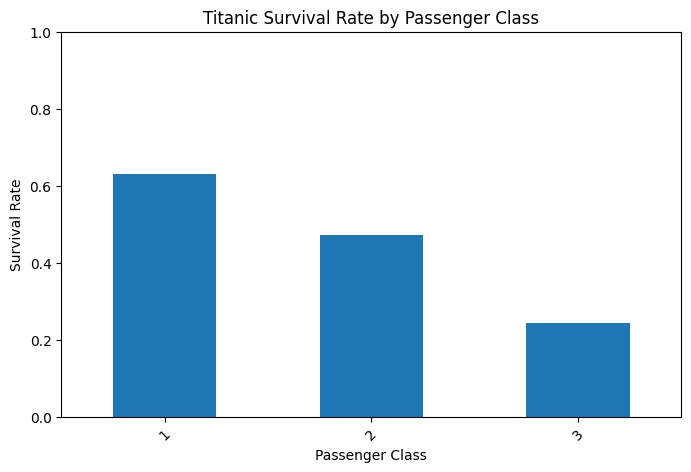

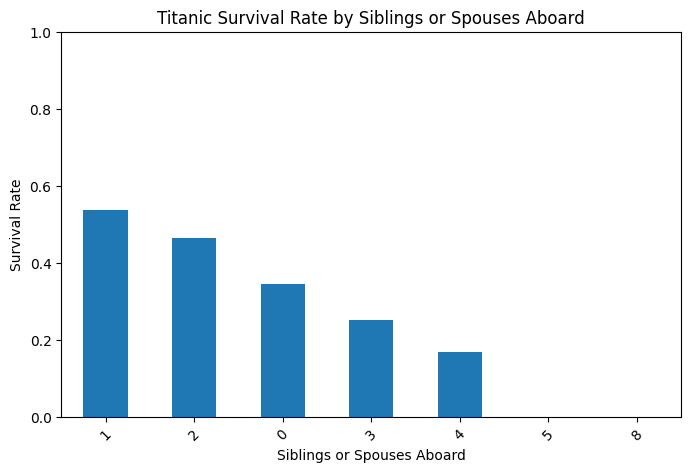

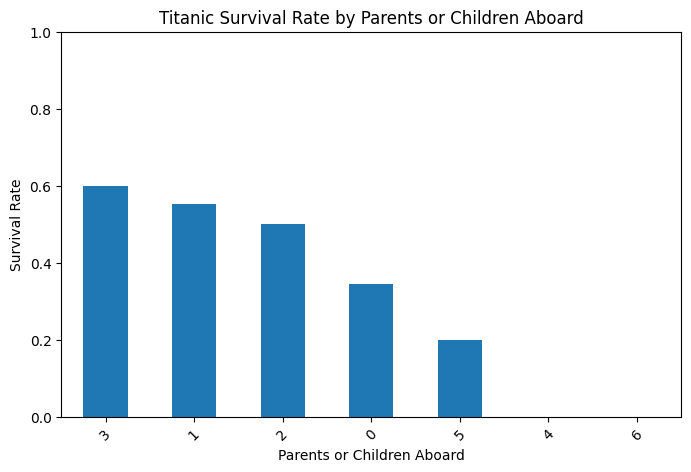

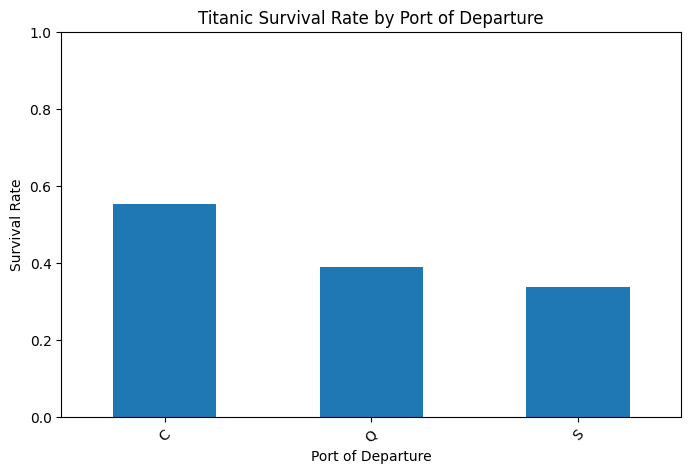

In [21]:
import matplotlib.pyplot as plt

def make_survival_chart(column, title, xlabel):
    rates = df.groupby(column)['Survived'].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    rates.plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Survival Rate')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.show()

make_survival_chart('AgeGroup', 'Titanic Survival Rate by Age Group', 'Age Group')
make_survival_chart('FareGroup', 'Titanic Survival Rate by Fare Group', 'Fare Group')
make_survival_chart('Sex', 'Titanic Survival Rate by Sex', 'Sex')
make_survival_chart('Pclass', 'Titanic Survival Rate by Passenger Class', 'Passenger Class')
make_survival_chart('SibSp', 'Titanic Survival Rate by Siblings or Spouses Aboard', 'Siblings or Spouses Aboard')
make_survival_chart('Parch', 'Titanic Survival Rate by Parents or Children Aboard', 'Parents or Children Aboard')
make_survival_chart('Embarked', 'Titanic Survival Rate by Port of Departure', 'Port of Departure')

In [17]:
print("Most Likely to Survive Character Profile")
print()
print("Based on the visualizations, the passenger most likely to survive would be a female passenger in first class, likely a child or adult, who paid a high fare, traveled with a small number of family members, and departed from Cherbourg. This profile is supported by the higher survival rates for females, first-class passengers, higher fare passengers, and passengers from Cherbourg.")

most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['FareGroup'] == 'High Fare')
]

most_likely[['Name', 'Age', 'AgeGroup', 'Sex', 'Pclass', 'Fare', 'FareGroup', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(10)

Most Likely to Survive Character Profile

Based on the visualizations, the passenger most likely to survive would be a female passenger in first class, likely a child or adult, who paid a high fare, traveled with a small number of family members, and departed from Cherbourg. This profile is supported by the higher survival rates for females, first-class passengers, higher fare passengers, and passengers from Cherbourg.


,Name,Age,AgeGroup,Sex,Pclass,Fare,FareGroup,SibSp,Parch,Embarked,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,Adult,female,1,71.2833,High Fare,1,0,C,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,Adult,female,1,53.1000,High Fare,1,0,S,1
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,Unknown,female,1,146.5208,High Fare,1,0,C,1
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,Middle Age,female,1,76.7292,High Fare,1,0,C,1
61,"Icard, Miss. Amelie",38.0,Adult,female,1,80.0000,High Fare,0,0,NaN,1
88,"Fortune, Miss. Mabel Helen",23.0,Adult,female,1,263.0000,High Fare,3,2,S,1
151,"Pears, Mrs. Thomas (Edith Wearne)",22.0,Adult,female,1,66.6000,High Fare,1,0,S,1
166,"Chibnall, Mrs. (Edith Martha Bowerman)",NaN,Unknown,female,1,55.0000,High Fare,0,1,S,1
195,"Lurette, Miss. Elise",58.0,Middle Age,female,1,146.5208,High Fare,0,0,C,1
215,"Newell, Miss. Madeleine",31.0,Adult,female,1,113.2750,High Fare,1,0,C,1


In [18]:
print("Least Likely to Survive Character Profile")
print()
print("Based on the visualizations, the passenger least likely to survive would be an adult male passenger in third class, who paid a low fare, had little or no family aboard, and departed from Southampton. This profile is supported by the lower survival rates for males, third-class passengers, lower fare passengers, and passengers traveling with no or very few companions.")

least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['FareGroup'] == 'Low Fare')
]

least_likely[['Name', 'Age', 'AgeGroup', 'Sex', 'Pclass', 'Fare', 'FareGroup', 'SibSp', 'Parch', 'Embarked', 'Survived']].head(10)

Least Likely to Survive Character Profile

Based on the visualizations, the passenger least likely to survive would be an adult male passenger in third class, who paid a low fare, had little or no family aboard, and departed from Southampton. This profile is supported by the lower survival rates for males, third-class passengers, lower fare passengers, and passengers traveling with no or very few companions.


,Name,Age,AgeGroup,Sex,Pclass,Fare,FareGroup,SibSp,Parch,Embarked,Survived
0,"Braund, Mr. Owen Harris",22.0,Adult,male,3,7.2500,Low Fare,1,0,S,0
4,"Allen, Mr. William Henry",35.0,Adult,male,3,8.0500,Low Fare,0,0,S,0
5,"Moran, Mr. James",NaN,Unknown,male,3,8.4583,Low Fare,0,0,Q,0
12,"Saundercock, Mr. William Henry",20.0,Adult,male,3,8.0500,Low Fare,0,0,S,0
26,"Emir, Mr. Farred Chehab",NaN,Unknown,male,3,7.2250,Low Fare,0,0,C,0
29,"Todoroff, Mr. Lalio",NaN,Unknown,male,3,7.8958,Low Fare,0,0,S,0
36,"Mamee, Mr. Hanna",NaN,Unknown,male,3,7.2292,Low Fare,0,0,C,1
37,"Cann, Mr. Ernest Charles",21.0,Adult,male,3,8.0500,Low Fare,0,0,S,0
42,"Kraeff, Mr. Theodor",NaN,Unknown,male,3,7.8958,Low Fare,0,0,C,0
45,"Rogers, Mr. William John",NaN,Unknown,male,3,8.0500,Low Fare,0,0,S,0


In [19]:
print("Real Passenger Examples")
print()
print("Most likely to survive passenger:")
print("Florence Briggs Cumings fits the most likely to survive profile because she was female, traveled in first class, paid a high fare, and survived the sinking. One interesting fact is that she was returning to New York after traveling in Europe with her husband, John Bradley Cumings.")
print()
print("Least likely to survive passenger:")
print("Owen Harris Braund fits the least likely to survive profile because he was male, traveled in third class, paid a low fare, and did not survive. One interesting fact is that he was a 22-year-old English ironmonger who was traveling for new opportunities in Canada.")
print()
print("Sources used for real passenger facts: Encyclopedia Titanica or similar Titanic passenger biography resources.")

Real Passenger Examples

Most likely to survive passenger:
Florence Briggs Cumings fits the most likely to survive profile because she was female, traveled in first class, paid a high fare, and survived the sinking. One interesting fact is that she was returning to New York after traveling in Europe with her husband, John Bradley Cumings.

Least likely to survive passenger:
Owen Harris Braund fits the least likely to survive profile because he was male, traveled in third class, paid a low fare, and did not survive. One interesting fact is that he was a 22-year-old English ironmonger who was traveling for new opportunities in Canada.

Sources used for real passenger facts: Encyclopedia Titanica or similar Titanic passenger biography resources.
